<a href="https://colab.research.google.com/github/SuryaTeja-aiml/ExplainableAI/blob/main/XAI_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[traffic prediction dataset](https://www.kaggle.com/datasets/olasomilabopopoola/traffic-prediction)

EDA

In [1]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.9 MB/s eta 0:00:00


In [2]:
pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.9/295.9 MB 1.2 MB/s eta 0:00:00


In [4]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=9da48d6512b87f01e79d67b7aa313977adfb8075d21f265727f8e37645c1e42a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


=== Part 1: Exploratory Data Analysis (EDA) ===
Traffic dataset shape: (48120, 4)
Weather dataset shape: (14592, 85)

Traffic dtypes:
DateTime    datetime64[ns]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object

Weather dtypes:
utc_timestamp                      datetime64[ns, UTC]
AT_temperature                                 float64
AT_radiation_direct_horizontal                 float64
AT_radiation_diffuse_horizontal                float64
BE_temperature                                 float64
                                          ...         
SI_radiation_direct_horizontal                 float64
SI_radiation_diffuse_horizontal                float64
SK_temperature                                 float64
SK_radiation_direct_horizontal                 float64
SK_radiation_diffuse_horizontal                float64
Length: 85, dtype: object

Missing values in Traffic:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

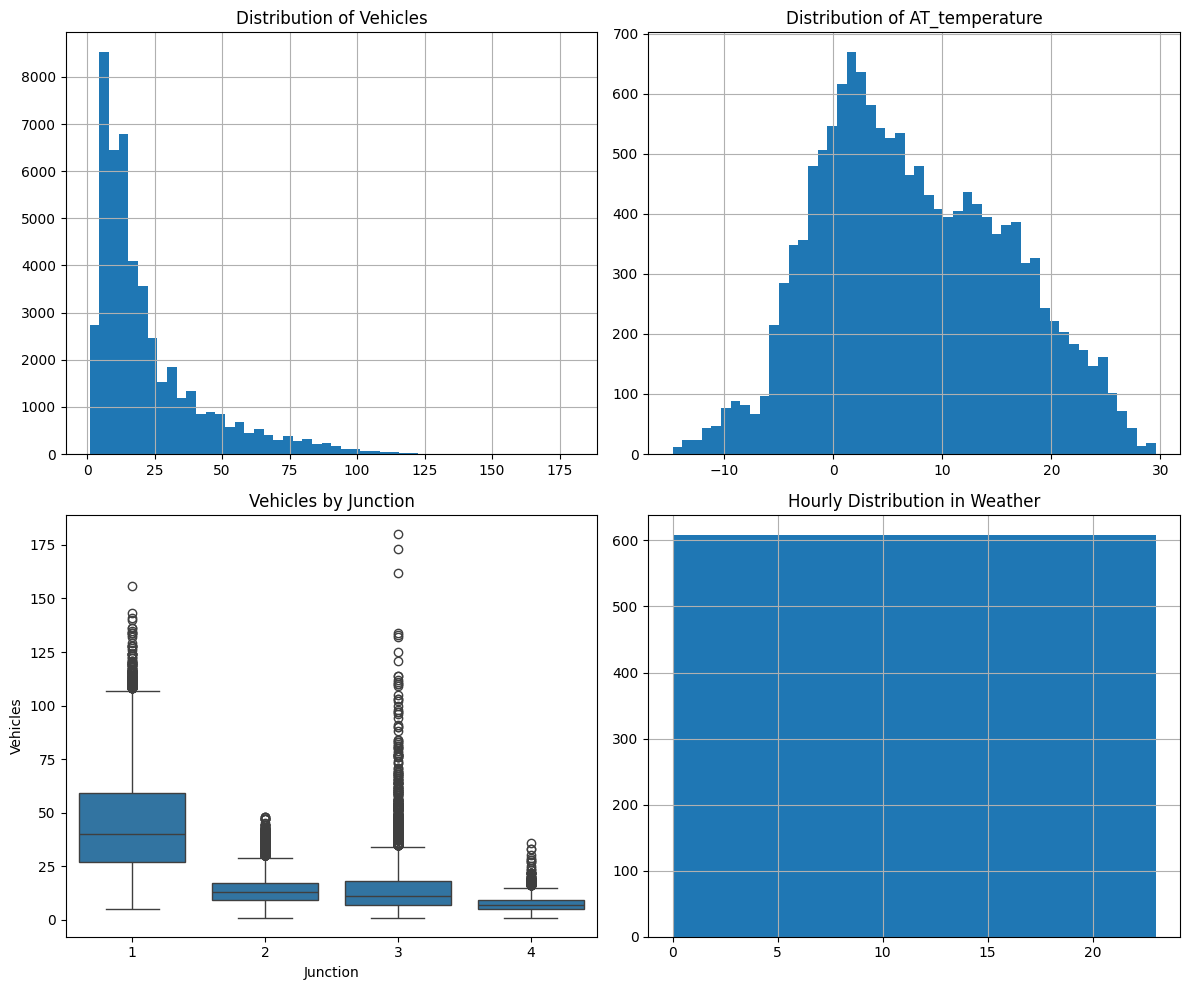

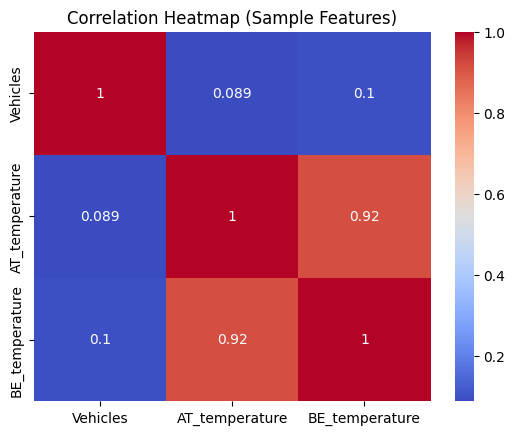

Target 'Vehicles' is continuous; treating as regression problem. No class imbalance to check.

=== Part 2: Preprocessing ===
Merged dataset shape: (48120, 87)

X_train dtypes before tensor conversion:
AT_temperature                     float64
AT_radiation_direct_horizontal     float64
AT_radiation_diffuse_horizontal    float64
BE_temperature                     float64
BE_radiation_direct_horizontal     float64
                                    ...   
Hour                               float64
Day                                float64
Month                              float64
Year                               float64
Weekday                            float64
Length: 92, dtype: object
Training set shape: (38496, 92)
Testing set shape: (9624, 92)

Actual data types within X_train.values:
{<class 'numpy.float64'>}

=== Part 3: Machine Learning Models (Regression) ===
Linear Regression: MSE=109.9096, MAE=7.6447, R2=0.7303
Decision Tree: MSE=28.8607, MAE=3.4567, R2=0.9292
Random Fore

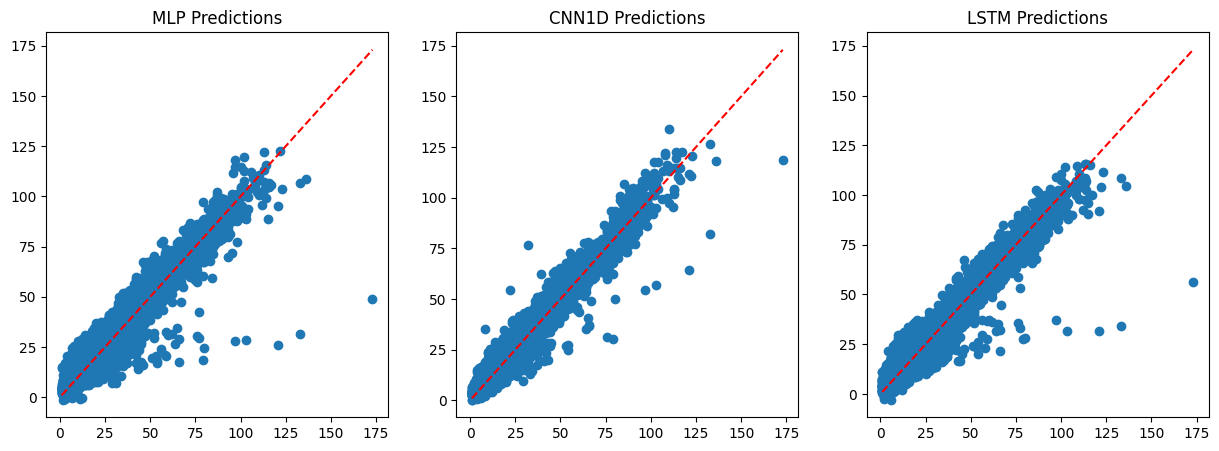


=== Part 5: Explainable AI (XAI) ===


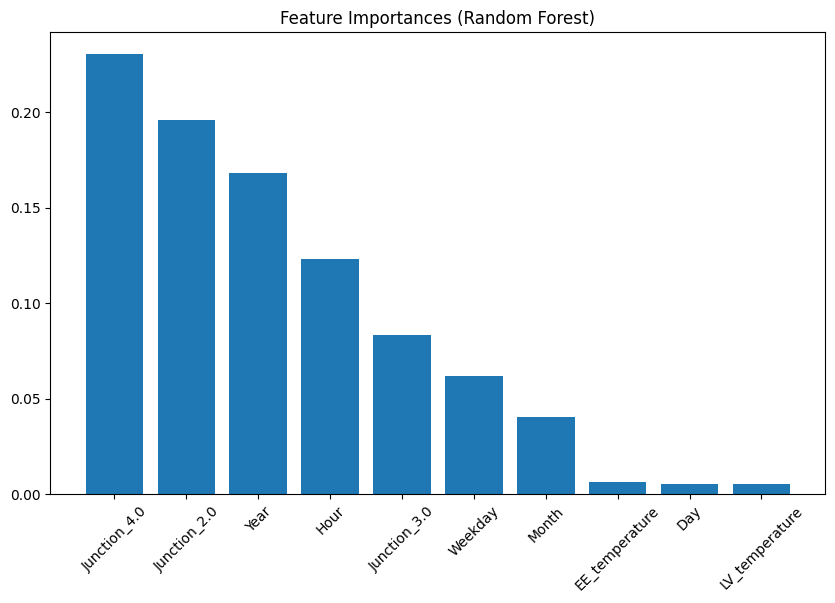

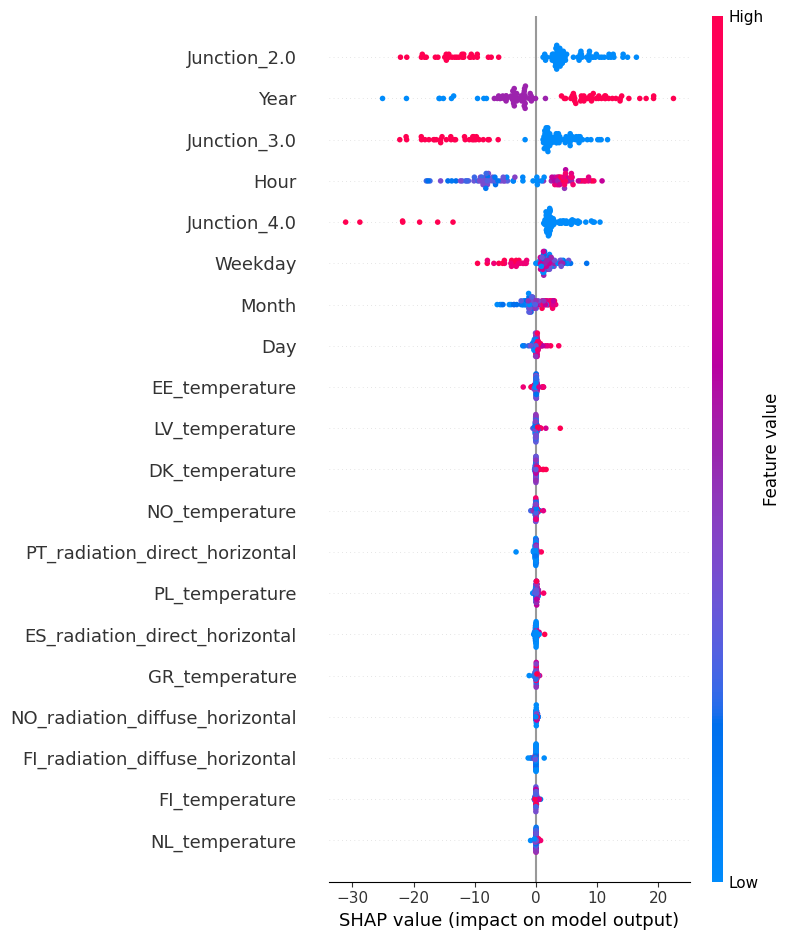

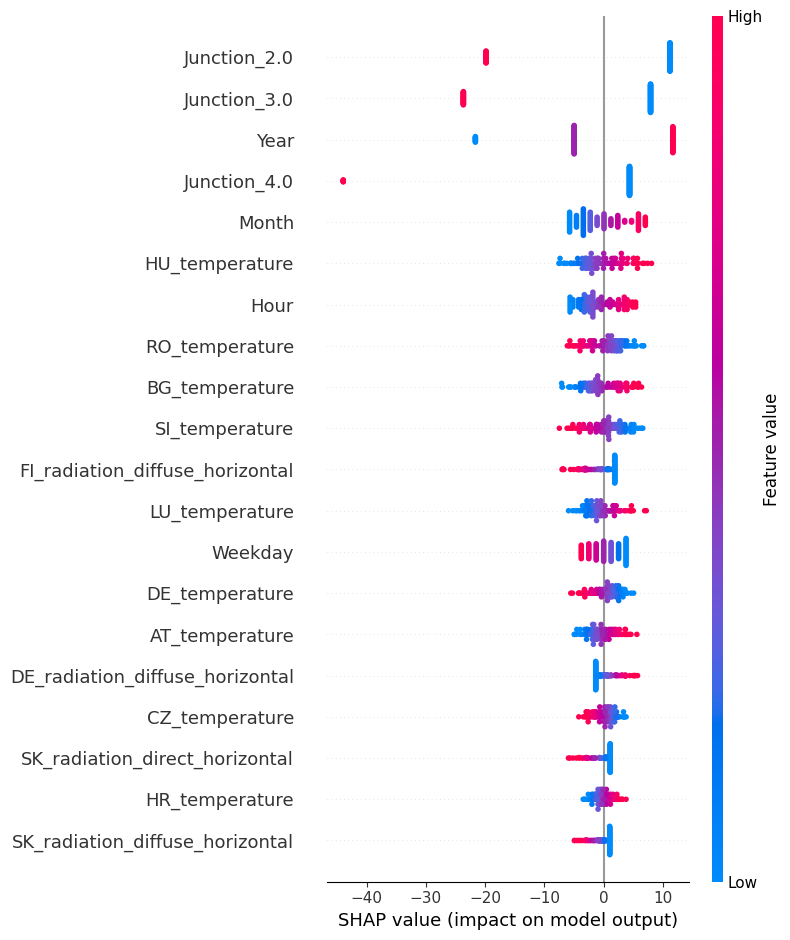

  0%|          | 0/10 [00:00<?, ?it/s]

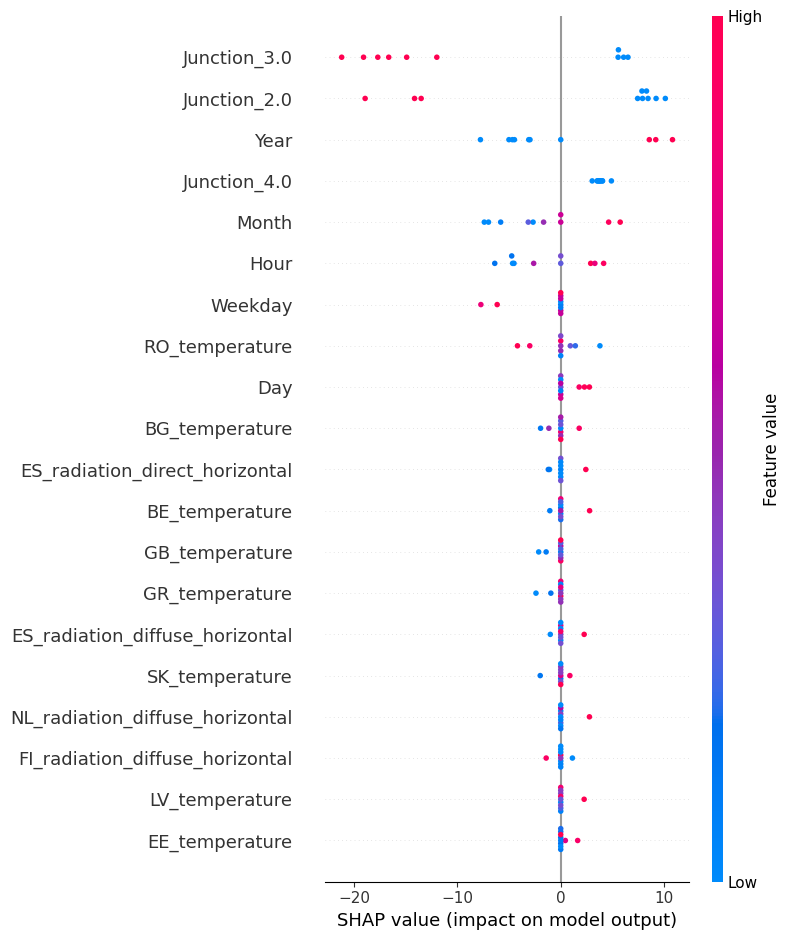

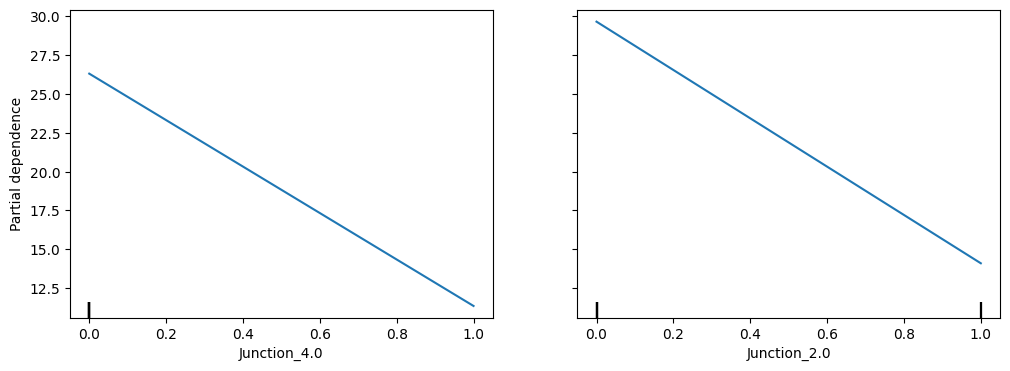


=== Part 6: Comparative Analysis ===
All Models Summary:
                          MSE        MAE        R2
Linear Regression  109.909617   7.644746  0.730314
Decision Tree       28.860661   3.456671  0.929184
Random Forest       14.304841   2.512451  0.964900
SVR                221.251969   8.491238  0.457113
KNN                318.468354  13.372278  0.218572
Gradient Boosting   59.878441   5.104921  0.853076
XGBoost             20.490316   2.909434  0.949723
MLP                 28.549667   3.419523  0.929948
CNN1D               16.171228   2.728197  0.960321
LSTM                25.224200   3.305537  0.938107

Best model based on R2: Random Forest with R2=0.9649

Discussion:
- ML models (e.g., Random Forest, XGBoost) generally perform well on tabular data with good interpretability via feature importance and SHAP.
- DL models (e.g., MLP) can capture non-linearities but may overfit on smaller datasets and are less interpretable.
- Trade-offs: ML offers higher interpretability (e.g., P

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Part 1: Exploratory Data Analysis (EDA)
print("=== Part 1: Exploratory Data Analysis (EDA) ===")

# Load datasets (assuming CSV files; adjust paths as needed)
traffic_df = pd.read_csv('traffic.csv', parse_dates=['DateTime'])
weather_df = pd.read_csv('weather.csv', parse_dates=['utc_timestamp'])

# Inspect shapes and datatypes
print("Traffic dataset shape:", traffic_df.shape)
print("Weather dataset shape:", weather_df.shape)
print("\nTraffic dtypes:")
print(traffic_df.dtypes)
print("\nWeather dtypes:")
print(weather_df.dtypes)

# Missing values
print("\nMissing values in Traffic:")
print(traffic_df.isnull().sum())
print("\nMissing values in Weather:")
print(weather_df.isnull().sum())

# Summary statistics
print("\nTraffic summary statistics:")
print(traffic_df.describe())
print("\nWeather summary statistics (first 10 columns):")
print(weather_df.describe().iloc[:, :10])

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
traffic_df['Vehicles'].hist(ax=axes[0,0], bins=50)
axes[0,0].set_title('Distribution of Vehicles')
weather_df['AT_temperature'].hist(ax=axes[0,1], bins=50)
axes[0,1].set_title('Distribution of AT_temperature')
sns.boxplot(x='Junction', y='Vehicles', data=traffic_df, ax=axes[1,0])
axes[1,0].set_title('Vehicles by Junction')
weather_df['utc_timestamp'].dt.hour.hist(ax=axes[1,1], bins=24)
axes[1,1].set_title('Hourly Distribution in Weather')
plt.tight_layout()
plt.savefig('eda_distributions.png')
plt.show()

# Correlation heatmap (select numerical features for traffic + sample weather)
# Remove timezone info from weather_df for merging
weather_df_eda = weather_df.copy() # Create a copy for EDA merge
weather_df_eda['utc_timestamp'] = weather_df_eda['utc_timestamp'].dt.tz_convert(None)
# Do not drop 'ID' from weather_df_eda as it does not exist; only traffic has 'ID'
merged_sample = traffic_df.merge(weather_df_eda[['utc_timestamp', 'AT_temperature', 'BE_temperature']],
                                 left_on='DateTime', right_on='utc_timestamp', how='inner')
numeric_cols = ['Vehicles', 'AT_temperature', 'BE_temperature']
corr_matrix = merged_sample[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Sample Features)')
plt.savefig('eda_correlation.png')
plt.show()

# No class imbalance check since it's regression (Vehicles is continuous target)
print("Target 'Vehicles' is continuous; treating as regression problem. No class imbalance to check.")

# Part 2: Preprocessing
print("\n=== Part 2: Preprocessing ===")

# Work on a copy of traffic_df to avoid modifying original
traffic_df_processed = traffic_df.copy()
# Drop ID column from processed traffic_df before merging (original traffic_df unchanged)
traffic_df_processed.drop('ID', axis=1, inplace=True)

# Merge datasets on datetime (weather_df unchanged)
# Remove timezone info from weather_df for merging (but keep original intact)
weather_df_processed = weather_df.copy()
weather_df_processed['utc_timestamp'] = weather_df_processed['utc_timestamp'].dt.tz_convert(None)
traffic_df_processed = traffic_df_processed.merge(weather_df_processed, left_on='DateTime', right_on='utc_timestamp', how='left')
traffic_df_processed.drop(['utc_timestamp'], axis=1, inplace=True)  # Drop unnecessary columns
print("Merged dataset shape:", traffic_df_processed.shape)

# Convert potential object type weather columns to numeric (coerce errors to NaN)
for col in traffic_df_processed.columns:
    if traffic_df_processed[col].dtype == 'object':
        traffic_df_processed[col] = pd.to_numeric(traffic_df_processed[col], errors='coerce')

# Handle missing values (impute numerical with mean); also ensure datetime features are handled post-merge
num_cols = traffic_df_processed.select_dtypes(include=[np.number]).columns.tolist()
imputer_num = SimpleImputer(strategy='mean')
traffic_df_processed[num_cols] = imputer_num.fit_transform(traffic_df_processed[num_cols])

# Categorical features: Junction (few unique, one-hot encode)
traffic_df_processed = pd.get_dummies(traffic_df_processed, columns=['Junction'], prefix='Junction', drop_first=True)

# Extract datetime features (hour, day, month, etc.) for better modeling
traffic_df_processed['Hour'] = traffic_df_processed['DateTime'].dt.hour
traffic_df_processed['Day'] = traffic_df_processed['DateTime'].dt.day
traffic_df_processed['Month'] = traffic_df_processed['DateTime'].dt.month
traffic_df_processed['Year'] = traffic_df_processed['DateTime'].dt.year
traffic_df_processed['Weekday'] = traffic_df_processed['DateTime'].dt.weekday
traffic_df_processed.drop('DateTime', axis=1, inplace=True)

# Ensure all columns are suitable numeric types (float64 for consistency, coerce errors)
for col in traffic_df_processed.columns:
    if col != 'Vehicles':  # Keep target as is for now
        traffic_df_processed[col] = pd.to_numeric(traffic_df_processed[col], errors='coerce')

# Update num_cols after datetime features and one-hot encoding (exclude target and any remaining NaNs)
num_cols = traffic_df_processed.select_dtypes(include=[np.number]).columns.tolist()
if 'Vehicles' in num_cols:
    num_cols.remove('Vehicles')  # Exclude target

# Re-impute any new NaNs from type conversion
if num_cols:
    imputer_num = SimpleImputer(strategy='mean')
    traffic_df_processed[num_cols] = imputer_num.fit_transform(traffic_df_processed[num_cols])

# Scale numerical features
scaler = StandardScaler()
if num_cols:
    traffic_df_processed[num_cols] = scaler.fit_transform(traffic_df_processed[num_cols])

# Ensure target is numeric
traffic_df_processed['Vehicles'] = pd.to_numeric(traffic_df_processed['Vehicles'], errors='coerce')

# Drop any rows with NaN in target (if any after coercion)
traffic_df_processed = traffic_df_processed.dropna(subset=['Vehicles'])

# Split into features and target
X = traffic_df_processed.drop('Vehicles', axis=1)
y = traffic_df_processed['Vehicles']

# Ensure X is numeric (float64)
X = X.astype(np.float64)

# Check data types before converting to tensors
print("\nX_train dtypes before tensor conversion:")
print(X.dtypes)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Ensure y is float for regression
y_train = y_train.astype(np.float64)
y_test = y_test.astype(np.float64)

# Check the actual data types within X_train.values
print("\nActual data types within X_train.values:")
unique_dtypes = set([type(item) for sublist in X_train.values for item in sublist])
print(unique_dtypes)


# Part 3: Machine Learning Models (Regression)
print("\n=== Part 3: Machine Learning Models (Regression) ===")

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Train and evaluate
results_ml = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results_ml[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    print(f"{name}: MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

# Summary table
ml_results_df = pd.DataFrame(results_ml).T
print("\nML Models Summary:")
print(ml_results_df)

# Part 4: Deep Learning Models (Regression)
print("\n=== Part 4: Deep Learning Models (Regression) ===")

# Prepare data for PyTorch - Explicitly convert to numpy arrays with float32 dtype
X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values.astype(np.float32), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float32).unsqueeze(1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define models
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Linear for regression
        return x

class CNN1D(nn.Module):
    def __init__(self, input_size):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * input_size, 64)  # Adjust based on input
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dim
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class LSTMModel(nn.Module):
    def __init__(self, input_size, seq_len=1, hidden_size=64):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # seq_len=1
        _, (hn, _) = self.lstm(x)
        x = torch.relu(self.fc1(hn[-1]))
        x = self.fc2(x)
        return x

# For simplicity, skip Hybrid and Autoencoder+Classifier as optional and not core for regression
# Train function
def train_model(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    return model

# Input size
input_size = X_train.shape[1]

# Train MLP
mlp_model = MLP(input_size)
mlp_model = train_model(mlp_model, train_loader)
mlp_model.eval()
with torch.no_grad():
    y_pred_mlp = mlp_model(X_test_tensor).numpy().flatten()
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"MLP: MSE={mse_mlp:.4f}, MAE={mae_mlp:.4f}, R2={r2_mlp:.4f}")

# Train CNN1D (treat features as sequence of length input_size, channels=1)
cnn_model = CNN1D(input_size)
cnn_model = train_model(cnn_model, train_loader)
cnn_model.eval()
with torch.no_grad():
    y_pred_cnn = cnn_model(X_test_tensor).numpy().flatten()
mse_cnn = mean_squared_error(y_test, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)
print(f"CNN1D: MSE={mse_cnn:.4f}, MAE={mae_cnn:.4f}, R2={r2_cnn:.4f}")

# Train LSTM (seq_len=1 for tabular)
lstm_model = LSTMModel(input_size)
lstm_model = train_model(lstm_model, train_loader)
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm = lstm_model(X_test_tensor).numpy().flatten()
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f"LSTM: MSE={mse_lstm:.4f}, MAE={mae_lstm:.4f}, R2={r2_lstm:.4f}")

# Confusion matrix not applicable for regression; use scatter plots instead
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(y_test, y_pred_mlp)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('MLP Predictions')
axes[1].scatter(y_test, y_pred_cnn)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('CNN1D Predictions')
axes[2].scatter(y_test, y_pred_lstm)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_title('LSTM Predictions')
plt.savefig('dl_predictions.png')
plt.show()

# Part 5: Explainable AI (XAI)
print("\n=== Part 5: Explainable AI (XAI) ===")

# Feature Importance (using Random Forest)
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:10]  # Top 10
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45)
plt.savefig('xai_feature_importance.png')
plt.show()

# SHAP values (for Random Forest and MLP; approx for DL)
# For RF
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test.iloc[:100])  # Sample for speed
shap.summary_plot(shap_values_rf, X_test.iloc[:100], feature_names=feature_names, show=False)
plt.savefig('xai_shap_rf.png')
plt.show()

# For Linear Regression (as proxy for simple model)
lr_model = models['Linear Regression']
explainer_lr = shap.LinearExplainer(lr_model, X_train)
shap_values_lr = explainer_lr.shap_values(X_test.iloc[:100])
shap.summary_plot(shap_values_lr, X_test.iloc[:100], feature_names=feature_names, show=False)
plt.savefig('xai_shap_lr.png')
plt.show()

# For MLP (KernelExplainer, slow; sample)
explainer_mlp = shap.KernelExplainer(lambda x: mlp_model(torch.tensor(x, dtype=torch.float32)).detach().numpy().flatten(),
                                     X_train.iloc[:50].values)  # Small background
shap_values_mlp = explainer_mlp.shap_values(X_test.iloc[:10].values)  # Few instances
shap.summary_plot(shap_values_mlp, X_test.iloc[:10], feature_names=feature_names, show=False)
plt.savefig('xai_shap_mlp.png')
plt.show()

# LIME (instance-level; for first test instance, using RF)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=feature_names, mode='regression')
exp = lime_explainer.explain_instance(X_test.iloc[0].values, rf_model.predict, num_features=10)
exp.show_in_notebook(show_table=True)
exp.save_to_file('xai_lime_rf.html')

# PDP & ICE plots (for top features, e.g., Hour and AT_temperature)
top_features = [feature_names[indices[0]], feature_names[indices[1]]] if len(indices) > 1 else ['Hour', 'AT_temperature']
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf_model, X_train, top_features, ax=ax)
plt.savefig('xai_pdp_ice.png')
plt.show()

# Part 6: Comparative Analysis
print("\n=== Part 6: Comparative Analysis ===")

# Combine results
dl_results = {
    'MLP': {'MSE': mse_mlp, 'MAE': mae_mlp, 'R2': r2_mlp},
    'CNN1D': {'MSE': mse_cnn, 'MAE': mae_cnn, 'R2': r2_cnn},
    'LSTM': {'MSE': mse_lstm, 'MAE': mae_lstm, 'R2': r2_lstm}
}
all_results_df = pd.DataFrame({**results_ml, **dl_results}).T
print("All Models Summary:")
print(all_results_df)

# Best model
best_model = all_results_df['R2'].idxmax()
print(f"\nBest model based on R2: {best_model} with R2={all_results_df.loc[best_model, 'R2']:.4f}")

# Discussion
print("\nDiscussion:")
print("- ML models (e.g., Random Forest, XGBoost) generally perform well on tabular data with good interpretability via feature importance and SHAP.")
print("- DL models (e.g., MLP) can capture non-linearities but may overfit on smaller datasets and are less interpretable.")
print("- Trade-offs: ML offers higher interpretability (e.g., PDP plots show how 'Hour' affects predictions), while DL may edge in accuracy for complex patterns.")
print("- Recommendation: For real-world traffic prediction, use Random Forest or XGBoost for balance of accuracy and explainability. Deploy with monitoring for weather feature drifts.")

# Save full results
all_results_df.to_csv('model_results.csv')
print("\nResults saved to 'model_results.csv'")